#**1 - Proyecto #1 - Análisis y Visualización de Datos**

##**1.1 - Cargar Librerias de Preprocesamiento de Datos**

In [ ]:
#========================================
#  Libreria para tratamiento de datos
#========================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
#========================================
#  Libreria para escalamiento o normalizacion de datos
#========================================
from sklearn.preprocessing import StandardScaler

In [ ]:
#========================================
#  Libreria para division de la dataset en datos de entrenamiento y datos de pruebas
#========================================
from sklearn.model_selection import train_test_split


In [ ]:
#========================================
#  Libreria para graficos profesionales
#========================================
import matplotlib.pyplot as plt
import seaborn as sns

##**1.2. Cargamos Librerías para problemas de Regresión (variable Y continua)**

In [ ]:
#========================================
#  Librerias para Algoritmo de Regresión Lineal
#  Sirve para realizar modelos que van a predecir el valor
#  de una variable Y que es de naturaleza numerica continua
#========================================
from sklearn.linear_model import LinearRegression

In [ ]:
#========================================
#  Libreria de Maquina de Soporte Vectorial SVM-R para problemas de Regresión
#========================================
# Entrenamiento Soporte Vectorial para Regresión
from sklearn.svm import SVR

##**1.3. Cargamos Librerías para problemas de Clasificación (variable Y discreta)**

In [ ]:
#========================================
# Libreria de Algoritmo de Regresión Logistica
#========================================
#  Sirve para crear modelos que van a predecir el valor
#  de una variable Y que es de naturaleza numerica discreta
# Entrenamiento Logistico
from sklearn.linear_model import LogisticRegression

In [ ]:
#========================================
#  Libreria de Maquina de Soporte Vectorial SVM-C para problemas de clasificación
#========================================
# Entrenamiento Soporte Vectorial para Clasificación
from sklearn.svm import SVC

##**1.4 - Cargamos librerías para Análisis de correlación entre variables Xs, y variables Xs con la Y**

In [ ]:
#========================================
#  Libreria para Analisis de correlacion entre Xs y Y
#========================================
import statsmodels.api as sm

##**1.5 - Cargamos librerías para medir la calidad del entrenamiento de los modelos de Aprendizaje Supervisado para clasificación**

In [ ]:
#========================================
# Cargamos librerias para medir la calidad del entrenamiento de los modelos de clasificación
#========================================
from sklearn.metrics import confusion_matrix, accuracy_score

#**2 - Cargar los Datos**

In [ ]:
# Obtenemos los datos y los cargamos en la carpeta Dataset1 de Google Drive
# Dataset: DatosEncuestasDietaFinal_v2.xlsx

##**2.1 - Cargamos la librería para conectarnos al goggle drive**

In [ ]:
# Cargamos la libreria para conecatrnos al goggle drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##**2.2 - Recuperamos la ruta donde esta cargado el dataset en Google Drive**

In [ ]:
# import pandas as pd
# /content/drive/MyDrive/Datasets1/TALLER_10_Dataset_EncuestasDieta_v3.xlsx

ruta_dataset = "/content/drive/MyDrive/Datasets1/TALLER_10_Dataset_EncuestasDieta_v3.xlsx"

df1_pacientes = pd.read_excel(ruta_dataset)

#**3 - Explorar los datos**

##**3.1 - Identificamos las variables disponibles**

In [ ]:
print('Variables de estudio disponibles en el dataframe:')
print(df1_pacientes.keys())

Variables de estudio disponibles en el dataframe:
Index(['id', 'sex', 'age', 'edc', 'wgt', 'hgt', 'eat_seq', 'meal_type',
       'bmi_cat', 'energy_100_truc'],
      dtype='object')


In [ ]:
# Variable dummy o innecesaria que se puede retirar
# id' - Secuencial numerico

#----------------------------------------
# Posibles Variables Xs
# 'sex' es el sexo del paciente
# 'age' Edad del paciente
# 'edc' Nivel de educacion
# 'wgt' Peso
# 'hgt' Estatura
# 'eat_seq' Numero de comidas que se sirve 1 a 7
# 'meal_type'  Tipo de alimento que se sirvio

#---------------------------------------------
# Posibles variavbles Ys
# 'bmi_cat'          Indice de Masa corporal  Y1
# 'energy_100_truc'  Cantida de Calorias que ha ingerido Y2


In [ ]:
# Visualizamos la estructura interna que uso python para cargar los datos
df1_pacientes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1455 non-null   int64  
 1   sex              1455 non-null   int64  
 2   age              1455 non-null   int64  
 3   edc              1433 non-null   float64
 4   wgt              1455 non-null   int64  
 5   hgt              1455 non-null   int64  
 6   eat_seq          1455 non-null   int64  
 7   meal_type        1455 non-null   int64  
 8   bmi_cat          1453 non-null   float64
 9   energy_100_truc  1455 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 113.8 KB


In [ ]:
# Visualizamos una muestra de los datos al inicio
df1_pacientes.head(10)

,id,sex,age,edc,wgt,hgt,eat_seq,meal_type,bmi_cat,energy_100_truc
0,32239,2,42,4.0,56,158,3,4,2.0,8600
1,32240,2,40,4.0,76,170,3,6,3.0,29920
2,32242,2,58,3.0,103,162,3,4,4.0,41700
3,32242,2,58,3.0,103,162,3,6,4.0,15250
4,32243,2,26,4.0,72,169,2,2,3.0,29920
5,32243,2,26,4.0,72,169,4,4,3.0,1998
6,32244,2,26,4.0,60,170,3,6,2.0,38400
7,32244,2,26,4.0,60,170,4,2,2.0,24400
8,32245,2,79,4.0,72,165,3,2,3.0,9800
9,32245,2,79,4.0,72,165,3,4,3.0,8600


In [ ]:
# Visualizamos una muestra de los datos al final del dataframe
df1_pacientes.tail(10)

,id,sex,age,edc,wgt,hgt,eat_seq,meal_type,bmi_cat,energy_100_truc
1445,33614,2,43,3.0,69,160,3,6,3.0,11900
1446,33614,2,43,3.0,69,160,4,4,3.0,16640
1447,33615,2,40,4.0,85,167,3,6,4.0,16800
1448,33615,2,40,4.0,85,167,4,4,4.0,11900
1449,33616,2,26,4.0,62,173,4,4,2.0,17850
1450,33617,2,49,3.0,54,170,4,6,2.0,250
1451,33618,2,37,NaN,63,167,2,6,2.0,7800
1452,33619,2,69,3.0,76,162,3,6,3.0,6950
1453,33619,2,69,3.0,76,162,6,4,3.0,8500
1454,33620,2,43,2.0,75,165,4,4,3.0,11900


In [ ]:
# Generamos una copia del dataframe para no alterar el original
df1_pacientes_cp = df1_pacientes.copy()

In [ ]:
# Retiramos variables innecesarias para este proyecto
# df1_pacientes_cp.drop(   'id'  , axis=1, inplace=True)

df1_pacientes_cp = df1_pacientes_cp.drop( ['id', 'energy_100_truc' ], axis=1)

In [ ]:
# Visualizamos el datafreame con las columnas a usar en el resto del análisis
df1_pacientes_cp.head(10)

,sex,age,edc,wgt,hgt,eat_seq,meal_type,bmi_cat
0,2,42,4.0,56,158,3,4,2.0
1,2,40,4.0,76,170,3,6,3.0
2,2,58,3.0,103,162,3,4,4.0
3,2,58,3.0,103,162,3,6,4.0
4,2,26,4.0,72,169,2,2,3.0
5,2,26,4.0,72,169,4,4,3.0
6,2,26,4.0,60,170,3,6,2.0
7,2,26,4.0,60,170,4,2,2.0
8,2,79,4.0,72,165,3,2,3.0
9,2,79,4.0,72,165,3,4,3.0


In [ ]:
df1_pacientes_cp.describe()

,sex,age,edc,wgt,hgt,eat_seq,meal_type,bmi_cat
count,1455.000000,1455.000000,1433.000000,1455.000000,1455.000000,1455.000000,1455.000000,1453.000000
mean,1.531271,45.424742,3.282624,74.443299,169.561512,3.527835,4.206186,2.698555
std,0.499193,13.290623,0.668807,15.370417,8.715046,1.447529,1.642402,0.738534
min,1.000000,19.000000,1.000000,40.000000,132.000000,1.000000,2.000000,1.000000
25%,1.000000,36.000000,3.000000,63.000000,164.000000,3.000000,2.000000,2.000000
50%,2.000000,43.000000,3.000000,73.000000,168.000000,3.000000,4.000000,3.000000
75%,2.000000,56.000000,4.000000,85.000000,175.000000,4.000000,6.000000,3.000000
max,2.000000,88.000000,4.000000,137.000000,207.000000,13.000000,6.000000,4.000000


In [ ]:
# Identificacion de datos vacios variables edc, bmi_cat
df1_pacientes_cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1455 entries, 0 to 1454
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sex        1455 non-null   int64  
 1   age        1455 non-null   int64  
 2   edc        1433 non-null   float64
 3   wgt        1455 non-null   int64  
 4   hgt        1455 non-null   int64  
 5   eat_seq    1455 non-null   int64  
 6   meal_type  1455 non-null   int64  
 7   bmi_cat    1453 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 91.1 KB


In [ ]:
df1_pacientes.shape

(1455, 10)

##**3.2 - Retiramos los registros cuya variable y esta vacia porque no sirven para entrenar el modelo**

In [ ]:
df1_pacientes_cp = df1_pacientes_cp[df1_pacientes['bmi_cat'].notna()]

In [ ]:
df1_pacientes_cp = df1_pacientes_cp[df1_pacientes['edc'].notna()]

<ipython-input-27-6132bc353352>:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df1_pacientes_cp = df1_pacientes_cp[df1_pacientes['edc'].notna()]


In [ ]:
# Identificacion de datos vacios variables edc, bmi_cat
df1_pacientes_cp.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1431 entries, 0 to 1454
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   sex        1431 non-null   int64  
 1   age        1431 non-null   int64  
 2   edc        1431 non-null   float64
 3   wgt        1431 non-null   int64  
 4   hgt        1431 non-null   int64  
 5   eat_seq    1431 non-null   int64  
 6   meal_type  1431 non-null   int64  
 7   bmi_cat    1431 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 100.6 KB


### Tabla de Clasificación de Status de Peso por Indice de Masa Corporal (BMI)

**bmi_cat** |**Weight Status**|  | **Adult BMI**|  
------------|----------------|--|---------------
1           |Underweight     |  | < 18.5       
2           |Normal weight   |  | 18.5 a 24.9    
3           |Overweight      |  | 25 a 29.9     
4           |Obesity         |  |  >= 30       

In [ ]:
# Inspeccion de tipos de Categorias BMI empleadas por encuestadores
df1_pacientes_cp = df1_pacientes_cp.sort_values('bmi_cat')
df1_pacientes_cp['bmi_cat'].unique()

array([1., 2., 3., 4.])

In [ ]:
# Calculo de Matriz de Correlacion
df1_pacientes_cp.corr()

,sex,age,edc,wgt,hgt,eat_seq,meal_type,bmi_cat
sex,1.000000,-0.093648,0.072527,-0.551163,-0.631762,-0.034046,-0.044545,-0.262995
age,-0.093648,1.000000,-0.267482,0.232963,-0.064889,0.038881,0.007460,0.304092
edc,0.072527,-0.267482,1.000000,-0.096293,0.019097,0.073696,-0.018166,-0.144308
wgt,-0.551163,0.232963,-0.096293,1.000000,0.598557,0.011234,0.025559,0.772336
hgt,-0.631762,-0.064889,0.019097,0.598557,1.000000,-0.003449,0.020279,0.095656
eat_seq,-0.034046,0.038881,0.073696,0.011234,-0.003449,1.000000,-0.056142,0.047115
meal_type,-0.044545,0.007460,-0.018166,0.025559,0.020279,-0.056142,1.000000,0.017624
bmi_cat,-0.262995,0.304092,-0.144308,0.772336,0.095656,0.047115,0.017624,1.000000


<Axes: >

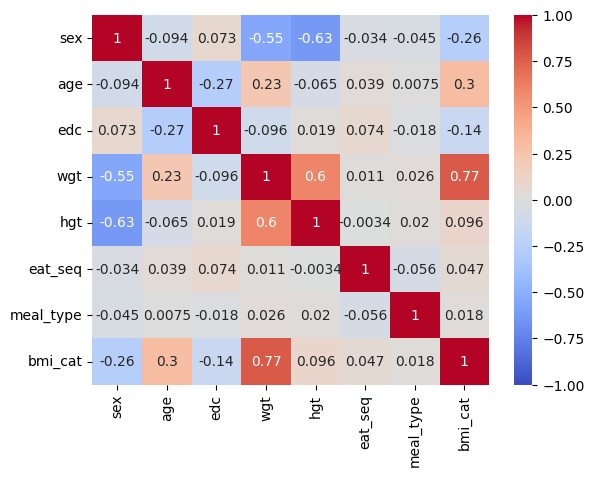

In [ ]:
# Ilustracion Grafica de Matriz de Correlacion
import seaborn as sns
sns.heatmap(df1_pacientes_cp.corr( ), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm')

<Axes: >

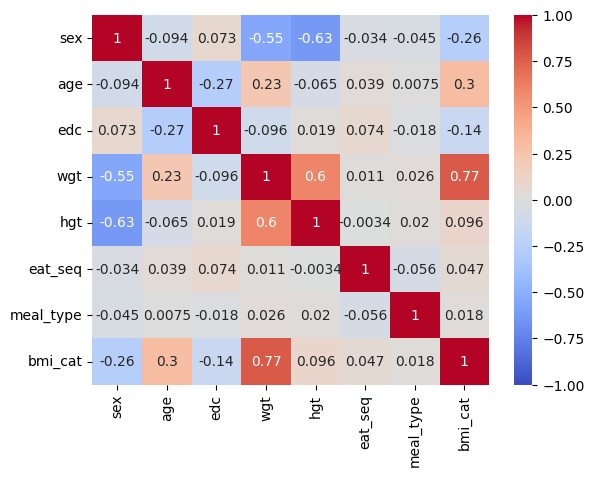

In [ ]:
# Ilustracion Grafica de Matriz de Correlacion
import seaborn as sns
sns.heatmap(df1_pacientes_cp.corr( method='pearson', min_periods=1, numeric_only=False ), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm')

<Axes: >

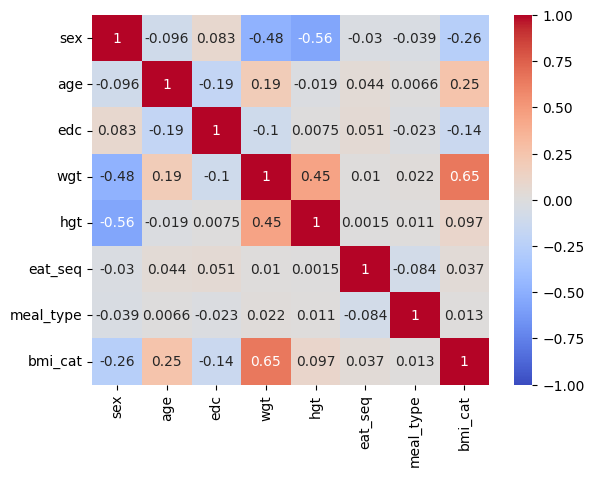

In [ ]:
# Ilustracion Grafica de Matriz de Correlacion
import seaborn as sns
sns.heatmap(df1_pacientes_cp.corr( method='kendall', min_periods=1, numeric_only=False ), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm')

<Axes: >

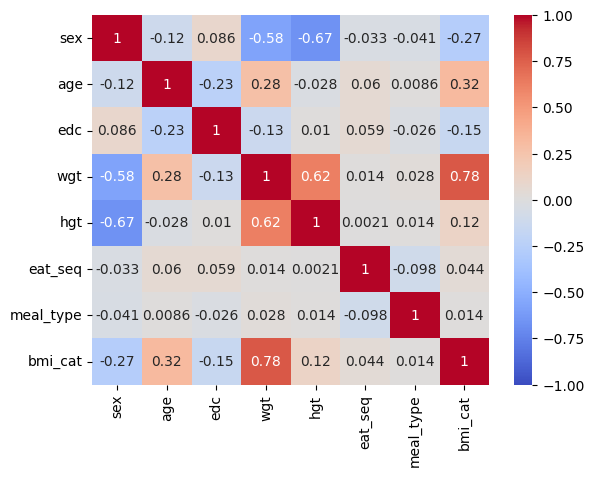

In [ ]:
# Ilustracion Grafica de Matriz de Correlacion
import seaborn as sns
sns.heatmap(df1_pacientes_cp.corr( method='spearman', min_periods=1, numeric_only=False ), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm')

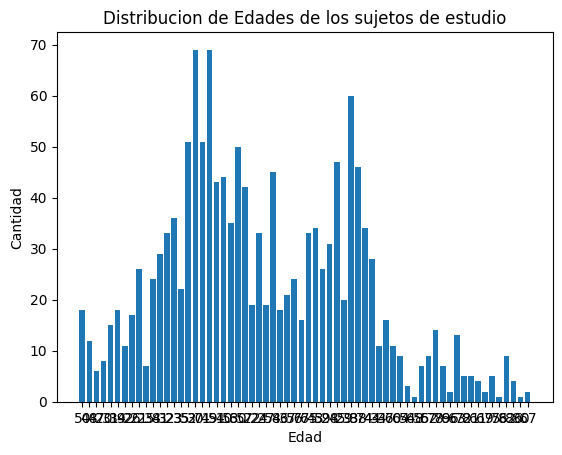

In [ ]:
# Visuaizacion Grafica de Histograma de Edades para identificar si la muestra
# muesta distribucion normal en los datos con las diveras edades esperadas.

count_ages = df1_pacientes_cp['age'].groupby(df1_pacientes_cp.age).agg('count')
namesbars = df1_pacientes_cp['age'].unique()
x_pos = np.arange(len(namesbars))
# Create bars and choose color
plt.bar(x_pos, count_ages)
# Add title and axis names
plt.title('Distribucion de Edades de los sujetos de estudio')
plt.xlabel('Edad')
plt.ylabel('Cantidad')
# Create names on the x axis
plt.xticks(x_pos, namesbars)
# Show graph
#plt.show()
plt.savefig('Grafico de Distribucion de Edades de la Muestra.png')

# 4 - Dar tramiento a los datos crudos para obtener una Vista Minable

##**4.1 Dividir los datos en entrada (Xs) y salida (Y)**

In [ ]:
# Obtencion de Variables Xs en un objeto numpy.ndarray
df_Xs = df1_pacientes_cp.iloc[  :  ,  0 : 7  ]

In [ ]:
type(df_Xs )

In [ ]:
df_Xs.head(5)

,sex,age,edc,wgt,hgt,eat_seq,meal_type
681,1,50,4.0,40,172,3,4
790,2,48,3.0,50,167,4,4
890,2,47,3.0,48,165,3,2
451,2,20,3.0,48,172,5,2
452,2,47,4.0,50,165,2,2


In [ ]:
# Obtencion de Variables Xs en un objeto numpy.ndarray
X = df1_pacientes_cp.iloc[  :  ,  0 : 7  ].values

In [ ]:
type(X)

numpy.ndarray

In [ ]:
X

array([[  1.,  50.,   4., ..., 172.,   3.,   4.],
       [  2.,  48.,   3., ..., 167.,   4.,   4.],
       [  2.,  47.,   3., ..., 165.,   3.,   2.],
       ...,
       [  2.,  55.,   3., ..., 152.,   3.,   4.],
       [  2.,  55.,   3., ..., 152.,   3.,   2.],
       [  2.,  52.,   4., ..., 160.,   3.,   4.]])

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2830c4f0d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2830c49a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830c4e510>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830a5a010>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2830a5ab90>],
 'means': []}

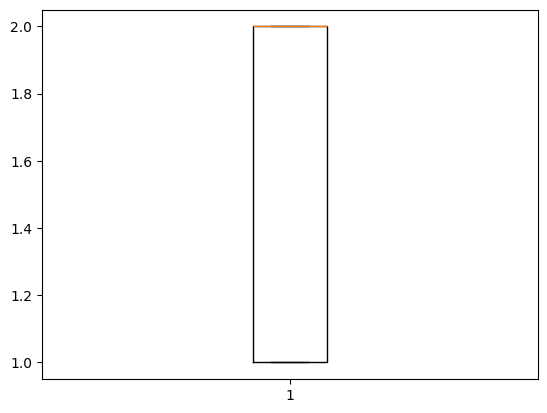

In [ ]:
# Opcion 1 usando una de las columnas del arreglo numpy
# le entregamos la columna de los datos sex en forma de lista extraida del arreglo numpy
plt.boxplot(X[:, 0])  # variable sex


{'whiskers': [<matplotlib.lines.Line2D at 0x7a2830ab0210>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2830ab1990>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830a9f690>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830ab30d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2830ab3bd0>],
 'means': []}

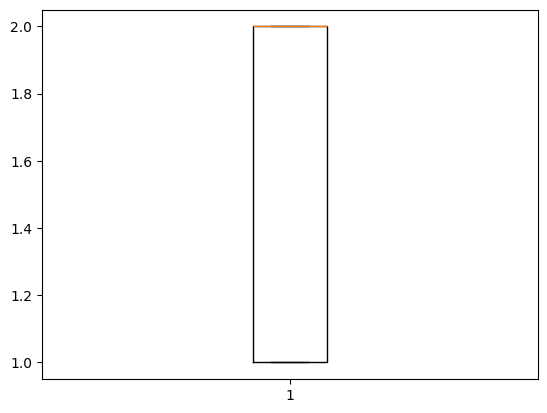

In [ ]:
# Opcion 2 usando una de las columnas del dataframe
# le entregamos la columna de los datos sex usando el nombre de la variable
# eso logra que se extraiga la data en forma de lista extraida del dataframe

plt.boxplot(df_Xs["sex"])

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2831c9eed0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2831ca8190>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2831c9e690>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2831ca9550>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2831ca9f10>],
 'means': []}

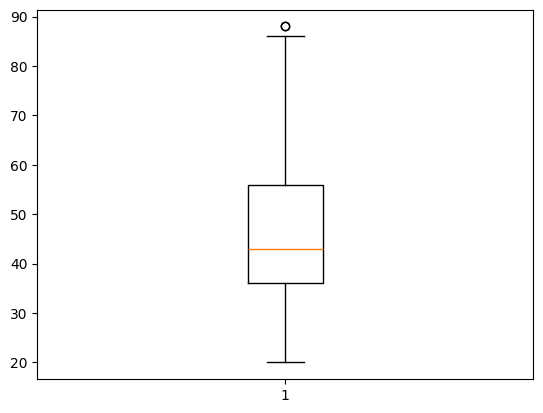

In [ ]:
plt.boxplot(X[:, 1])  # variable age #SUPERIOR

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2831d05810>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2831d06c10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2831d05010>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2831d07fd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2831cf9650>],
 'means': []}

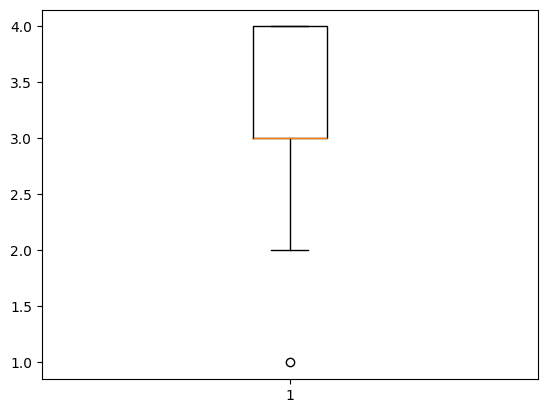

In [ ]:
plt.boxplot(X[:, 2])  # variable edc, INFERIROR posee outlayer

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2831b709d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2831b71d10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2831b70090>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2831b73050>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2831b60d90>],
 'means': []}

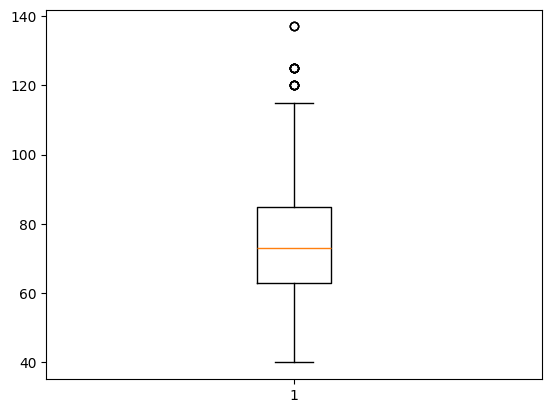

In [ ]:
plt.boxplot(X[:, 3])  # variable wgt, posee outlayer SUPEIROR

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2831bc55d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2831bc6950>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2831bc4cd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2831bc7d10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2831bd0590>],
 'means': []}

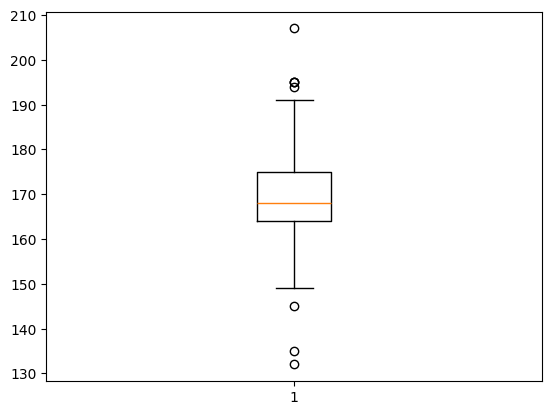

In [ ]:
plt.boxplot(X[:, 4])  # variable hgt, posee outlayer superiores E INFERIOR

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2831c2cfd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2831c2dd10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2831c2c750>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2831c2f450>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2831c2fdd0>],
 'means': []}

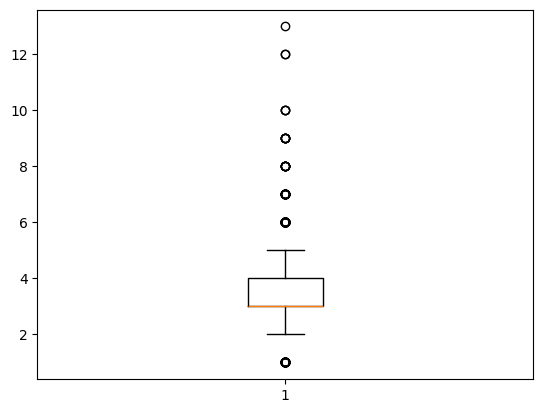

In [ ]:
plt.boxplot(X[:, 5])  # variable 'eat_seq', posee outlayer superiores e Inferiores

{'whiskers': [<matplotlib.lines.Line2D at 0x7a2830927c90>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2830931450>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830922bd0>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830932c10>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2830933550>],
 'means': []}

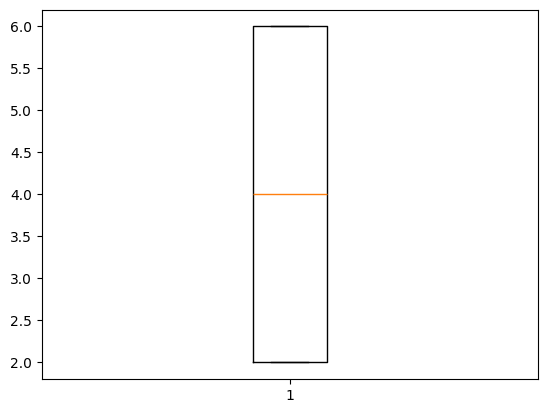

In [ ]:
plt.boxplot(X[:, 6])  # variable

##**4.2. Proceso de corrección de los Ouliers**

###**4.2.1 - Corrigiendo Outliers superiores**

In [ ]:
# ==========================================================================
# Tratamiento de Outliers Superiores (Valores atipicos, extremos superiores)
# ------ Se setea el indice de la columna con outlayer inferior
# ----- este bloque se ejeucta para cada variable con Outlayer inferior
# ----- col = 2da, 4ta, 5ta, 6ta
#      indice 1 ,  3 ,  4 ,  5
# ==========================================================================

In [ ]:
import numpy as np

In [ ]:
# ----- Funcion para rastreo del mejor percentil superior para ajuste de outlayers superiores
def HallaMejorPercentilSup(micol,  maximo, minimo, miCotaSup):
	for x in range(maximo, minimo, -1):
		valor_tope_actual = np.quantile(X[:,micol] , x/100)
		print(f"Percentil {x} = {np.round(valor_tope_actual,micol)},col = {micol}, CotaSup = {miCotaSup}")
		if(valor_tope_actual <= miCotaSup):
			return x , valor_tope_actual

In [ ]:
# ----- se deber ejecutar el bloque, ajustar el valor  de col y
# ------ ejecutarlo para cada variable con outlayer superior
# indice 1 ,  3 ,  4 ,  5

In [ ]:
col = 1
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)

IQR=q3-q1

CotaSup= q3 + 1.5 * IQR

PercentilSupSugerido , ValorTecho = HallaMejorPercentilSup(col, 99, 80, CotaSup)

X[:,col] = np.where(X[:,col] > ValorTecho, ValorTecho, X[:,col] )

Percentil 99 = 81.0,col = 1, CotaSup = 86.0


{'whiskers': [<matplotlib.lines.Line2D at 0x7a283098add0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2830998690>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830c2aa10>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830999e50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a283099a950>],
 'means': []}

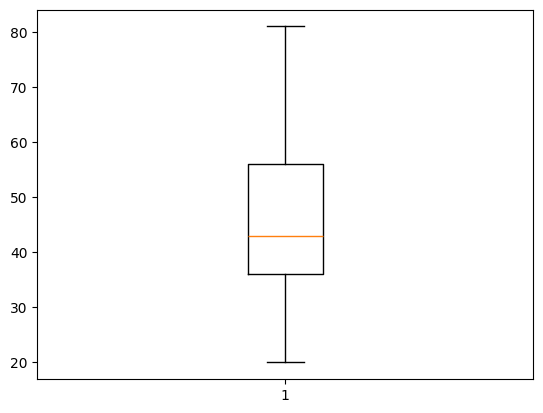

In [ ]:
plt.boxplot(X[:, 1])  # variable age #SUPERIOR

In [ ]:
col = 3
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaSup=q3+1.5*IQR
PercentilSupSugerido , ValorTecho = HallaMejorPercentilSup(col, 99, 80, CotaSup)
X[:,col] = np.where(X[:,col] > ValorTecho, ValorTecho, X[:,col] )

Percentil 99 = 120.0,col = 3, CotaSup = 118.0
Percentil 98 = 110.0,col = 3, CotaSup = 118.0


{'whiskers': [<matplotlib.lines.Line2D at 0x7a28309f2fd0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a28309f8690>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a28309f2410>],
 'medians': [<matplotlib.lines.Line2D at 0x7a28309f9dd0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a28309fa710>],
 'means': []}

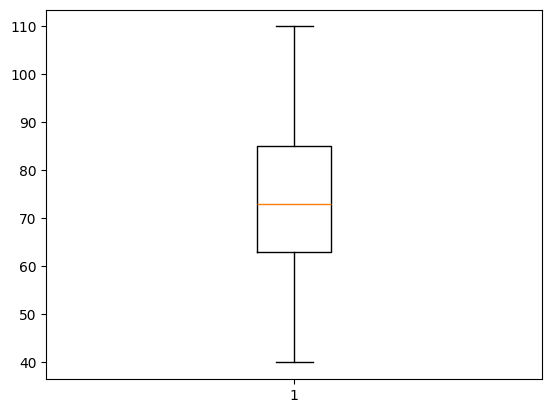

In [ ]:
plt.boxplot(X[:, 3])

In [ ]:
col = 4
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaSup=q3+1.5*IQR
PercentilSupSugerido , ValorTecho = HallaMejorPercentilSup(col, 99, 80, CotaSup)
X[:,col] = np.where(X[:,col] > ValorTecho, ValorTecho, X[:,col] )

Percentil 99 = 189.0,col = 4, CotaSup = 191.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7a2830864290>,
 'caps': [<matplotlib.lines.Line2D at 0x7a2830865a90>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a283085f650>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830867290>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2830867d90>],
 'means': []}

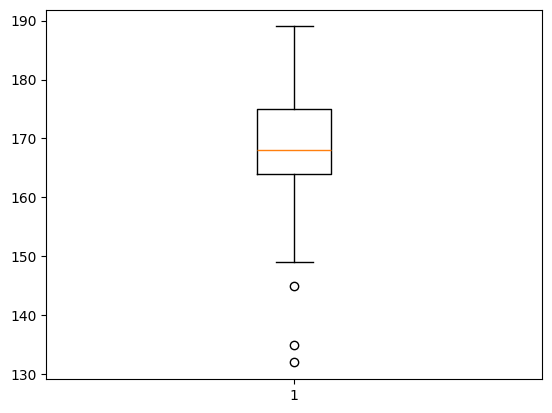

In [ ]:
plt.boxplot(X[:, 4])

In [ ]:
col = 5
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaSup=q3+1.5*IQR
PercentilSupSugerido , ValorTecho = HallaMejorPercentilSup(col, 99, 80, CotaSup)
X[:,col] = np.where(X[:,col] > ValorTecho, ValorTecho, X[:,col] )

Percentil 99 = 8.0,col = 5, CotaSup = 5.5
Percentil 98 = 7.0,col = 5, CotaSup = 5.5
Percentil 97 = 7.0,col = 5, CotaSup = 5.5
Percentil 96 = 6.0,col = 5, CotaSup = 5.5
Percentil 95 = 6.0,col = 5, CotaSup = 5.5
Percentil 94 = 6.0,col = 5, CotaSup = 5.5
Percentil 93 = 6.0,col = 5, CotaSup = 5.5
Percentil 92 = 5.0,col = 5, CotaSup = 5.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7a28306d3190>,
 'caps': [<matplotlib.lines.Line2D at 0x7a28306e0a10>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a28306d2590>],
 'medians': [<matplotlib.lines.Line2D at 0x7a28306e2350>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a28306e2f10>],
 'means': []}

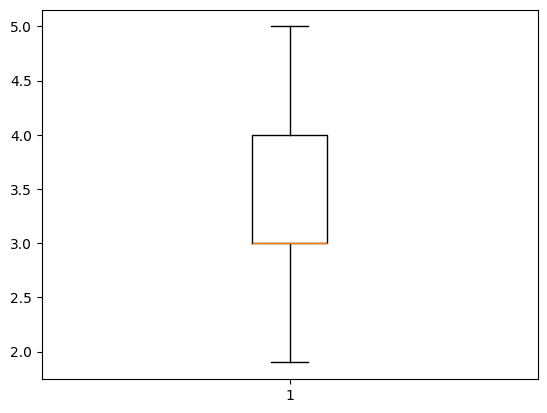

In [ ]:
plt.boxplot(X[:, 5])

###**4.2.2 - Correccion de outlier inferiores**

In [ ]:
# =========================================================================
# Tratamiento de Outliers Inferiores (Valores atipicos, extremos Inferiores)
# ------ Se setea el indice de la columna con outlayer inferior
# ----- este bloque se ejeucta para cada variable con Outlayer inferior
#       columna 3ra 5ta  6ta
# ----- incide   2,  4,  5
# ==========================================================================

In [ ]:
# ----- Funcion creada para rastreo del mejor percentil inferior para ajuste de outlayers inferiores
def HallaMejorPercentilInf(micol,  minimo, maximo, miCotaInf):
  valor_tope_previo = 0
  valor_x_previo = 0
  for x in range(minimo, maximo, +1):
    valor_tope_actual = np.quantile(X[:,micol] , x/100)
    print(f"Percentil {x} = {np.round(valor_tope_actual,micol)},col = {micol}, CotaInf = {miCotaInf}")
    if(valor_tope_actual >= miCotaInf):
      return x, valor_tope_actual

In [ ]:
col = 2
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaInf=q1-1.5*IQR
PercentilInfSugerido , ValorPiso = HallaMejorPercentilInf(col, 1, 20, CotaInf)
X[:,col] = np.where(X[:,col] < ValorPiso, ValorPiso, X[:,col] )

Percentil 1 = 2.0,col = 2, CotaInf = 1.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7a283079cc10>,
 'caps': [<matplotlib.lines.Line2D at 0x7a283079e550>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830793f50>],
 'medians': [<matplotlib.lines.Line2D at 0x7a283079fd50>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a28307a4950>],
 'means': []}

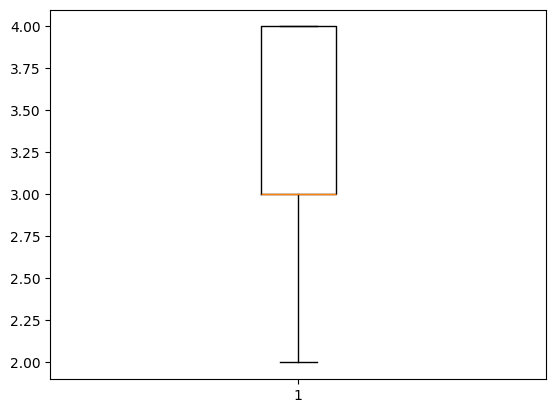

In [ ]:
plt.boxplot(X[:, 2])

In [ ]:
col = 4
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaInf=q1-1.5*IQR
PercentilInfSugerido , ValorPiso = HallaMejorPercentilInf(col, 1, 20, CotaInf)
X[:,col] = np.where(X[:,col] < ValorPiso, ValorPiso, X[:,col] )

Percentil 1 = 150.0,col = 4, CotaInf = 147.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7a2830809390>,
 'caps': [<matplotlib.lines.Line2D at 0x7a283080abd0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830808710>],
 'medians': [<matplotlib.lines.Line2D at 0x7a2830810450>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a2830810f10>],
 'means': []}

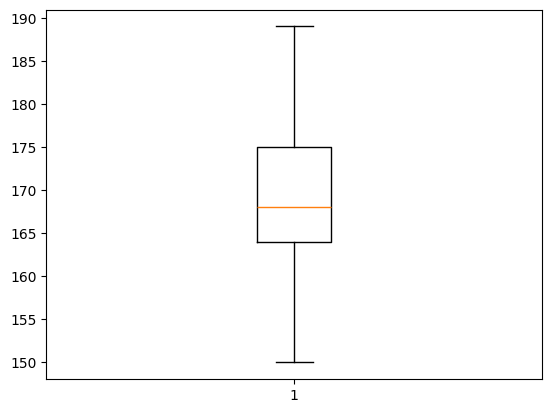

In [ ]:
plt.boxplot(X[:, 4])

In [ ]:
col = 5
q3=np.quantile(X[:,col] , 0.75)
q1=np.quantile(X[:,col] , 0.25)
IQR=q3-q1
CotaInf=q1-1.5*IQR
PercentilInfSugerido , ValorPiso = HallaMejorPercentilInf(col, 1, 20, CotaInf)
X[:,col] = np.where(X[:,col] < ValorPiso, ValorPiso, X[:,col] )

Percentil 1 = 1.0,col = 5, CotaInf = 1.5
Percentil 2 = 1.0,col = 5, CotaInf = 1.5
Percentil 3 = 1.9,col = 5, CotaInf = 1.5


{'whiskers': [<matplotlib.lines.Line2D at 0x7a28306768d0>,
 'caps': [<matplotlib.lines.Line2D at 0x7a283067c0d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7a2830675d90>],
 'medians': [<matplotlib.lines.Line2D at 0x7a283067d8d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7a283067e490>],
 'means': []}

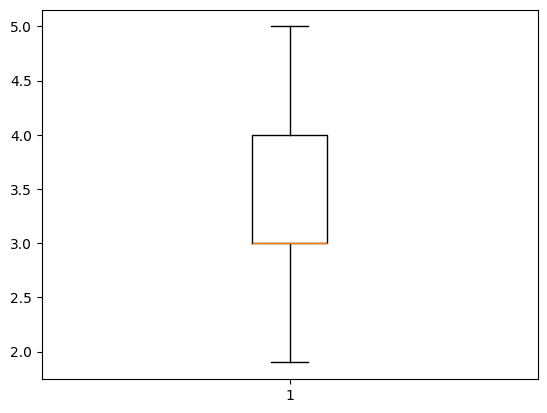

In [ ]:
plt.boxplot(X[:, 5])

##**4.3 - Escalado de Variables con dominios diferentes**

In [ ]:
# Verificamos si en nuestras variables numericas existen dominios distintos
# es decir rangos de valores minimo maximo muy diferentes en las divers variables

df_Xs.describe()

# Se detecan rangos muy diferentes, por lo que se procede a escalar

,sex,age,edc,wgt,hgt,eat_seq,meal_type
count,1431.000000,1431.000000,1431.000000,1431.000000,1431.000000,1431.000000,1431.000000
mean,1.531796,45.477289,3.284416,74.304682,169.529001,3.519217,4.202655
std,0.499162,13.332358,0.667551,15.186928,8.705056,1.445326,1.642365
min,1.000000,20.000000,1.000000,40.000000,132.000000,1.000000,2.000000
25%,1.000000,36.000000,3.000000,63.000000,164.000000,3.000000,2.000000
50%,2.000000,43.000000,3.000000,73.000000,168.000000,3.000000,4.000000
75%,2.000000,56.000000,4.000000,85.000000,175.000000,4.000000,6.000000
max,2.000000,88.000000,4.000000,137.000000,207.000000,13.000000,6.000000


###**4.3.1 - Escalado basado en método estadistico de Estandarización**

In [ ]:
from sklearn.preprocessing import StandardScaler
#traemos esta libreria

In [ ]:
#crea un objeto escalador
obj_sc = StandardScaler()

In [ ]:
#aqui estamos escalado las variables
# obj_arr_np_X_sc

obj_X_sc = obj_sc.fit_transform( X )

In [ ]:
# Los valores promedios que empleo para escalar
obj_sc.scale_

array([ 0.49898799, 13.28143983,  0.66544592, 14.53622114,  8.51713678,
        1.0726801 ,  1.64179128])

In [ ]:
# Mostramos los valores de la varianza de cada variable que se empleo para escalar
obj_sc.var_  #

array([  0.24898902, 176.39664394,   0.44281828, 211.30172515,
        72.54161887,   1.1506426 ,   2.69547862])

In [ ]:
type(obj_X_sc)

numpy.ndarray

In [ ]:
obj_X_sc

array([[-1.06574898,  0.34173886,  1.0742942 , ...,  0.29094137,
        -0.37895636, -0.1234356 ],
       [ 0.93830725,  0.19115277, -0.42845751, ..., -0.29611038,
         0.55328802, -0.1234356 ],
       [ 0.93830725,  0.11585973, -0.42845751, ..., -0.53093107,
        -0.37895636, -1.34161724],
       ...,
       [ 0.93830725,  0.71820406, -0.42845751, ..., -2.05726561,
        -0.37895636, -0.1234356 ],
       [ 0.93830725,  0.71820406, -0.42845751, ..., -2.05726561,
        -0.37895636, -1.34161724],
       [ 0.93830725,  0.49232494,  1.0742942 , ..., -1.11798282,
        -0.37895636, -0.1234356 ]])

###**4.3.2 - Escalado basado en método estadistico de Normalización**

In [ ]:
from sklearn.preprocessing import MinMaxScaler

In [ ]:
ob_sc_norm = MinMaxScaler()

X_sc_nor = ob_sc_norm.fit_transform(X)

In [ ]:
print(X_sc_nor)

[[0.         0.49180328 1.         ... 0.56410256 0.35483871 0.5       ]
 [1.         0.45901639 0.5        ... 0.43589744 0.67741935 0.5       ]
 [1.         0.44262295 0.5        ... 0.38461538 0.35483871 0.        ]
 ...
 [1.         0.57377049 0.5        ... 0.05128205 0.35483871 0.5       ]
 [1.         0.57377049 0.5        ... 0.05128205 0.35483871 0.        ]
 [1.         0.52459016 1.         ... 0.25641026 0.35483871 0.5       ]]


# 6 - Dividir los datos en Entrenamiento (train) en Pruebas (test)

# 7 - Crear el Modelo

# 8 - Entrenar el Modelo

# 9 - Evaluar el modelo con metricas de calidad

# 10 - Hacer pruebas de laboratorio para verificar el funcionamiento del modelo